#### Question 2 : Implement moving average filter using CUDA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda

In [6]:
!ls /kaggle/input/datasets/ffatty/plain-text-wikipedia-simpleenglish/

1of2  2of2  AllCombined.txt


In [7]:
file_path = "/kaggle/input/datasets/ffatty/plain-text-wikipedia-simpleenglish/AllCombined.txt"

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

print("Total Lines:", len(lines))

Total Lines: 2052699


In [8]:
signal = np.array(
    [len(line.split()) for line in lines if len(line.strip()) > 0],
    dtype=np.float32
)

print("Signal Size:", len(signal))
print(signal[:20])

Signal Size: 977335
[  1.  31.  30.  40.  51. 103.  70.  30.  69.  75.  16.   1.  31.  44.
  97.  40.  32.  55.  81.  68.]


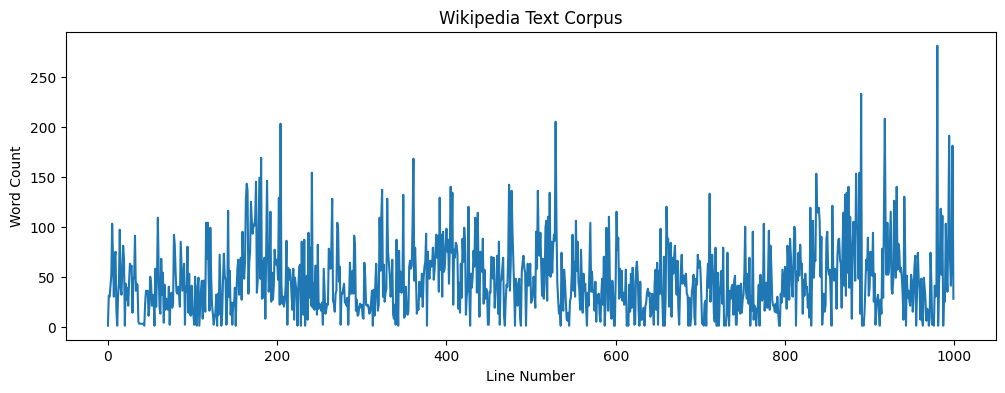

In [9]:
plt.figure(figsize=(12,4))
plt.plot(signal[:1000])

plt.title("Wikipedia Text Corpus")
plt.xlabel("Line Number")
plt.ylabel("Word Count")

plt.show()

In [10]:
@cuda.jit
def moving_average_kernel(signal, output, window):

    idx = cuda.grid(1)

    if idx < output.size:

        total = 0.0

        for j in range(window):
            total += signal[idx + j]

        output[idx] = total / window

In [11]:
window_size = 5

output_size = len(signal) - window_size + 1

filtered = np.zeros(
    output_size,
    dtype=np.float32
)

print("Output Size:", output_size)

Output Size: 977331


In [12]:
d_signal = cuda.to_device(signal)
d_filtered = cuda.to_device(filtered)

In [13]:
threads_per_block = 256

blocks_per_grid = (
    output_size +
    threads_per_block - 1
) // threads_per_block

moving_average_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_signal,
    d_filtered,
    window_size
)

In [14]:
filtered = d_filtered.copy_to_host()

print(filtered[:20])

[30.6 51.  58.8 58.8 64.6 69.4 52.  38.2 38.4 33.4 37.8 42.6 48.8 53.6
 61.  55.2 47.4 49.6 44.  35.6]


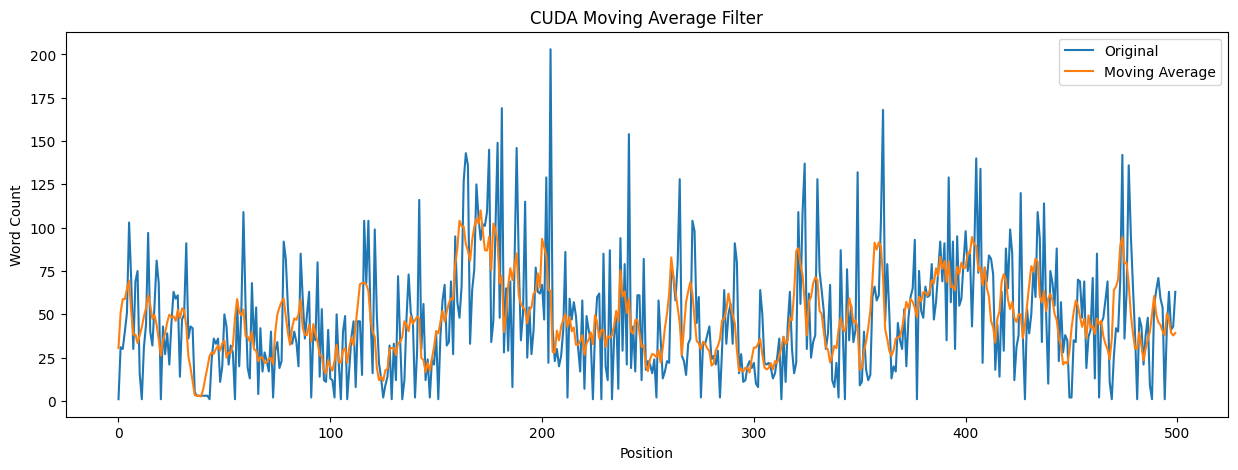

In [15]:
plt.figure(figsize=(15,5))

plt.plot(signal[:500],
         label="Original")

plt.plot(filtered[:500],
         label="Moving Average")

plt.legend()

plt.title("CUDA Moving Average Filter")
plt.xlabel("Position")
plt.ylabel("Word Count")

plt.show()